# Cardiac Patient Monitoring System — ML Analysis 

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

# Introduction

This notebook brings together a complete machine learning workflow, starting from Exploratory Data Analysis (EDA) and feature engineering and ending with model training, comparison, and final evaluation.

The objective of this project is to build a classification model using the Heart Disease dataset to predict whether a person has heart disease. Before building the model, we will investigate which characteristics and lifestyle factors are associated with heart disease by exploring the dataset and its features, understanding the population represented in the data, and examining the distribution of heart disease cases.

One of the main challenges in this dataset is the imbalance between the two classes, as the majority of respondents do not have heart disease while only a smaller percentage do. This means that accuracy alone may not be enough to evaluate the models, and we will need to consider other evaluation metrics when measuring their performance.

These observations will guide our analysis and feature engineering. The project will then follow a complete machine learning pipeline, from data cleaning and analysis to feature engineering, preprocessing, model training, comparison, and final evaluation.

<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

# Dataset Overview



**Dataset:** Personal Key Indicators of Heart Disease (CDC BRFSS 2020), `heart_2020_raw.csv`.
319,795 survey respondents, 17 lifestyle/health features, binary target (`HeartDisease`: Yes/No).
Source: CDC Behavioral Risk Factor Surveillance System, distributed via Kaggle
(kamilpytlak/[personal-key-indicators-of-heart-disease](https://www.kaggle.com/datasets/kamilpytlak/personal-key-indicators-of-heart-disease)).

### Why this dataset, and how it differs from a small clinical dataset

This is a large dataset with almost **300K rows** and a heavily **imbalanced target**: about **91% have no disease** and **9% have the disease**. It mainly contains categorical, self-reported lifestyle information, rather than detailed clinical measurements from a small, balanced dataset.

This affects how we approach the project:

* **Accuracy can be misleading.** A model could predict "no disease" for everyone and still achieve around 91% accuracy while failing to identify any actual disease cases. Therefore, we focus more on **precision, recall, F1-score, and ROC-AUC**.

* **More complex models are not always better.** Because the dataset is large and mostly categorical, a highly complex model may be slower, harder to interpret, and may mainly learn the majority class. Therefore, this project focuses on simpler, well-regularized, and interpretable models, such as **Logistic Regression** and a **shallow Random Forest**, while evaluating their ability to detect the minority disease class.


**data dictionary :**

| Column | Meaning | Type |
|---|---|---|
| HeartDisease | ever told they had coronary heart disease or MI | **target** (Yes/No) |
| BMI | body mass index | continuous |
| Smoking | smoked >= 100 cigarettes in lifetime | binary |
| AlcoholDrinking | heavy drinker (per CDC definition) | binary |
| Stroke | ever had a stroke | binary |
| PhysicalHealth | days of poor physical health, last 30 days | continuous (0-30) |
| MentalHealth | days of poor mental health, last 30 days | continuous (0-30) |
| DiffWalking | serious difficulty walking/climbing stairs | binary |
| Sex | Male/Female | binary categorical |
| AgeCategory | age bracket (10 bins, e.g. "55-59") | ordinal categorical |
| Race | self-reported race/ethnicity | nominal categorical |
| Diabetic | diabetes status (Yes/No/borderline/during pregnancy) | categorical (4 levels) |
| PhysicalActivity | physical activity in last 30 days | binary |
| GenHealth | self-rated general health (Poor..Excellent) | ordinal categorical |
| SleepTime | average hours of sleep | continuous |
| Asthma | has asthma | binary |
| KidneyDisease | has kidney disease | binary |
| SkinCancer | has had skin cancer | binary |

**Target variable:** `HeartDisease` (Yes/No)




<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

# Section 1 :  Loading Libraries & Dataset

### 1. Load all libraries needed to run all the code cells and the raw dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                              RocCurveDisplay, classification_report, balanced_accuracy_score)
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

RANDOM_STATE = 42
sns.set_theme(style="white")
sns.color_palette("hls", 8)
plt.rcParams["figure.figsize"] = (7, 4)
pd.set_option("display.max_columns", None)
print("Libraries loaded.")


Libraries loaded.


**A note on compute settings below:** this notebook was developed on a single-core machine.
`n_estimators=150` and 3-fold cross-validation were chosen to keep runtime reasonable on that
hardware while still giving stable estimates on a ~240K-row training set; on a typical multi-core
laptop, feel free to raise these (e.g. `n_estimators=300`, `cv=5`) for marginally more stable
numbers -- the qualitative conclusions should not change.

------------------


### 2. Then inspect its structure, columns, and data types.

In [2]:
df = pd.read_csv("heart_2020_raw.csv")
print("Shape:", df.shape)
df.head()


Shape: (319795, 18)


,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 319795 entries, 0 to 319794
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   HeartDisease      319795 non-null  object 
 1   BMI               319795 non-null  float64
 2   Smoking           319795 non-null  object 
 3   AlcoholDrinking   319795 non-null  object 
 4   Stroke            319795 non-null  object 
 5   PhysicalHealth    319795 non-null  float64
 6   MentalHealth      319795 non-null  float64
 7   DiffWalking       319795 non-null  object 
 8   Sex               319795 non-null  object 
 9   AgeCategory       319795 non-null  object 
 10  Race              319795 non-null  object 
 11  Diabetic          319795 non-null  object 
 12  PhysicalActivity  319795 non-null  object 
 13  GenHealth         319795 non-null  object 
 14  SleepTime         319795 non-null  float64
 15  Asthma            319795 non-null  object 
 16  KidneyDisease     31

In [4]:
print(df["HeartDisease"].value_counts())
print()
print(df["HeartDisease"].value_counts(normalize=True).round(4))


HeartDisease
No     292422
Yes     27373
Name: count, dtype: int64

HeartDisease
No     0.9144
Yes    0.0856
Name: proportion, dtype: float64


### Noticing a huge imbalance in the target class
only **8.6% of respondents** report having heart disease. Every modeling and evaluation decision from here on is shaped by this
imbalance 


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

# Section 2 : Data Preparation

### 1. Check for missing values, duplicates, and invalid values.

In [5]:
print("Missing values per column:")
print(df.isna().sum())
print()
print("Total missing cells:", df.isna().sum().sum())


Missing values per column:
HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64

Total missing cells: 0


HeartDisease        0
BMI                 0
Smoking             0
AlcoholDrinking     0
Stroke              0
PhysicalHealth      0
MentalHealth        0
DiffWalking         0
Sex                 0
AgeCategory         0
Race                0
Diabetic            0
PhysicalActivity    0
GenHealth           0
SleepTime           0
Asthma              0
KidneyDisease       0
SkinCancer          0
dtype: int64



Total missing cells: 0


In [6]:
n_dupes = df.duplicated().sum()
print(f"Duplicate rows: {n_dupes} ({n_dupes/len(df):.2%} of the dataset)")

Duplicate rows: 18078 (5.65% of the dataset)


In [7]:
df_clean = df.drop_duplicates().reset_index(drop=True)
print("Shape after removing exact duplicate rows:", df_clean.shape)

Shape after removing exact duplicate rows: (301717, 18)


In [8]:
# Invalid-value checks on the continuous columns
for col in ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime"]:
    print(f"{col}: min={df_clean[col].min()}, max={df_clean[col].max()}")

BMI: min=12.02, max=94.85
PhysicalHealth: min=0.0, max=30.0
MentalHealth: min=0.0, max=30.0
SleepTime: min=1.0, max=24.0


----------

### 2. Encode categorical variables appropriately for their type (binary, ordinal, or nominal).


All four continuous columns fall within plausible physiological ranges (BMI, days-per-month
counts capped at 30, and sleep hours), so no invalid-value correction is needed here 


**Encoding categorical variables** -- three different treatments, depending on the variable's type:

1. **Binary Yes/No columns** -> mapped to 1/0 directly.
2. **`AgeCategory`** -> this is *ordinal*, not nominal (bins are naturally ordered), so instead of
   one-hot encoding it into 10 separate columns, it is converted to a single numeric feature using
   the midpoint of each age bracket. This preserves the ordering information a model can use, and
   is itself a small piece of feature engineering.
3. **`GenHealth`** -> also ordinal (Poor < Fair < Good < Very good < Excellent), mapped to an
   ordered numeric scale 0-4.
4. **`Race` and `Diabetic`** -> genuinely nominal (no natural order), so these remain as categorical
   columns and are one-hot encoded inside the modeling pipeline in Section 4.


In [9]:
binary_map = {"Yes": 1, "No": 0}
binary_cols = ["Smoking", "AlcoholDrinking", "Stroke", "DiffWalking",
               "PhysicalActivity", "Asthma", "KidneyDisease", "SkinCancer"]

for col in binary_cols:
    df_clean[col] = df_clean[col].map(binary_map)

df_clean["Sex"] = df_clean["Sex"].map({"Male": 1, "Female": 0})
df_clean["HeartDisease"] = df_clean["HeartDisease"].map(binary_map)

df_clean[binary_cols + ["Sex", "HeartDisease"]].head()


,Smoking,AlcoholDrinking,Stroke,DiffWalking,PhysicalActivity,Asthma,KidneyDisease,SkinCancer,Sex,HeartDisease
0,1,0,0,0,1,1,0,1,0,0
1,0,0,1,0,1,0,0,0,0,0
2,1,0,0,0,1,1,0,0,1,0
3,0,0,0,0,0,0,0,1,0,0
4,0,0,0,1,1,0,0,0,0,0


In [10]:
age_midpoints = {
    "18-24": 21, "25-29": 27, "30-34": 32, "35-39": 37, "40-44": 42,
    "45-49": 47, "50-54": 52, "55-59": 57, "60-64": 62, "65-69": 67,
    "70-74": 72, "75-79": 77, "80 or older": 82,
}
df_clean["AgeNumeric"] = df_clean["AgeCategory"].map(age_midpoints)

genhealth_map = {"Poor": 0, "Fair": 1, "Good": 2, "Very good": 3, "Excellent": 4}
df_clean["GenHealthNumeric"] = df_clean["GenHealth"].map(genhealth_map)

print(df_clean["Diabetic"].value_counts())
print()
df_clean[["AgeCategory", "AgeNumeric", "GenHealth", "GenHealthNumeric"]].head()


Diabetic
No                         251796
Yes                         40589
No, borderline diabetes      6776
Yes (during pregnancy)       2556
Name: count, dtype: int64



,AgeCategory,AgeNumeric,GenHealth,GenHealthNumeric
0,55-59,57,Very good,3
1,80 or older,82,Very good,3
2,65-69,67,Fair,1
3,75-79,77,Good,2
4,40-44,42,Very good,3


`Diabetic` has four categories, including two ambiguous ones ("No, borderline diabetes" and
"Yes (during pregnancy)"). Rather than silently collapsing these into a binary Yes/No (which would
throw away real clinical distinctions), we keep all four categories and one-hot encode them inside
the pipeline -- the model can then learn a distinct weight for "borderline" and "pregnancy-related"
cases instead of having that nuance erased upfront.


<hr style="height: 5px; background-color: #5A98C4 ; border: none;">

# Section 3 : EDA & Statistics

> Before building the model, we will explore the different characteristics, lifestyle behaviors, health conditions, and health indicators in the dataset and investigate how they are associated with the presence of heart disease.
> 

### Note 
> Because the dataset has around **300,000 rows**, plotting every single data point can make some graphs slow and difficult to read. Therefore, for certain plots, **a Stratified random sample is used only to make the visualization faster and clearer.**

In [11]:
df_clean.describe(include="all").T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
HeartDisease,301717.0,NaN,NaN,NaN,0.090353,0.286687,0.0,0.0,0.0,0.0,1.0
BMI,301717.0,NaN,NaN,NaN,28.44197,6.468134,12.02,24.03,27.41,31.65,94.85
Smoking,301717.0,NaN,NaN,NaN,0.422267,0.493921,0.0,0.0,0.0,1.0,1.0
AlcoholDrinking,301717.0,NaN,NaN,NaN,0.071527,0.257704,0.0,0.0,0.0,0.0,1.0
Stroke,301717.0,NaN,NaN,NaN,0.039984,0.195923,0.0,0.0,0.0,0.0,1.0
PhysicalHealth,301717.0,NaN,NaN,NaN,3.572298,8.140656,0.0,0.0,0.0,2.0,30.0
MentalHealth,301717.0,NaN,NaN,NaN,4.121475,8.128288,0.0,0.0,0.0,4.0,30.0
DiffWalking,301717.0,NaN,NaN,NaN,0.147009,0.354115,0.0,0.0,0.0,0.0,1.0
Sex,301717.0,NaN,NaN,NaN,0.470792,0.499147,0.0,0.0,0.0,1.0,1.0
AgeCategory,301717,13,65-69,31670,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 2. Class balance 

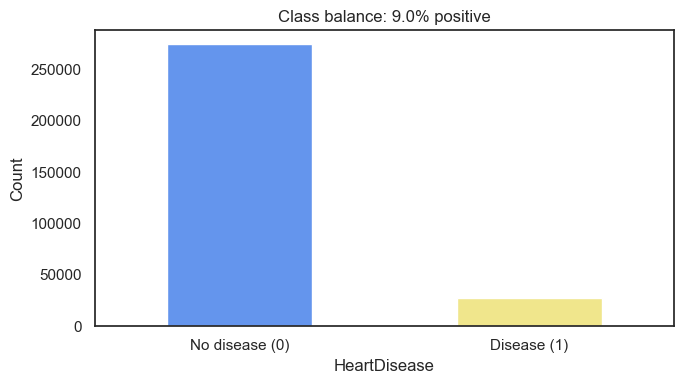

In [12]:
fig, ax = plt.subplots()
df_clean["HeartDisease"].value_counts().sort_index().plot(
    kind="bar", color=["cornflowerblue", "khaki"], ax=ax
)
ax.set_xticklabels(["No disease (0)", "Disease (1)"], rotation=0)
ax.set_ylabel("Count")
ax.set_title(f"Class balance: {df_clean['HeartDisease'].mean():.1%} positive")
plt.tight_layout()
plt.show()

### 3. Distributions of continuous features

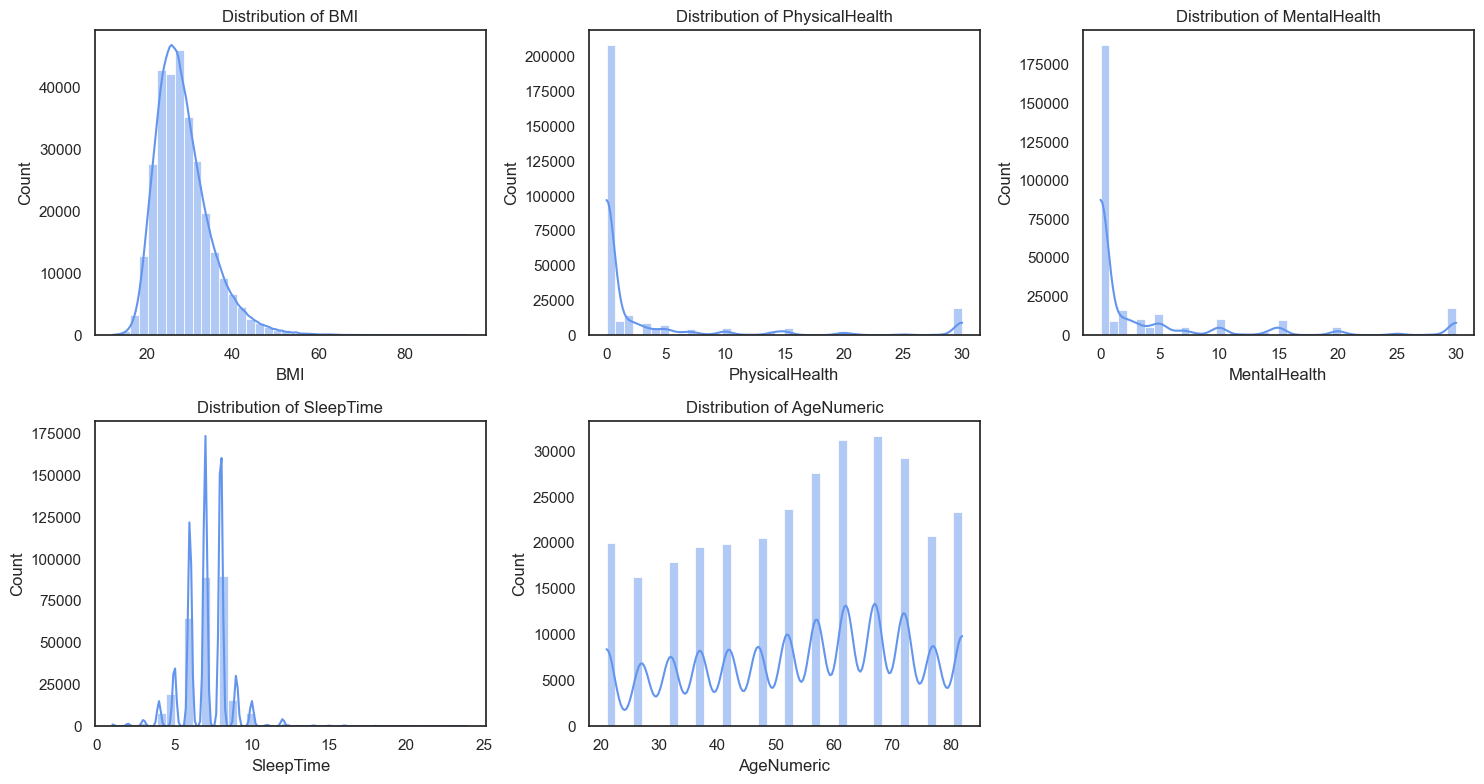

In [13]:
continuous_cols = ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime", "AgeNumeric"]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
for i, col in enumerate(continuous_cols):
    sns.histplot(df_clean[col], kde=True, ax=axes[i], color="cornflowerblue", bins=40)
    axes[i].set_title(f"Distribution of {col}")
axes[-1].axis("off")
plt.tight_layout()
plt.show()


#### Summary of Continuous Numerical Features

* **BMI (Body Mass Index):** Mostly normal (bell-shaped) with a peak around 26–28, but skewed to the right due to a small group of individuals with unusually high BMI values up to 80+.
* **Physical Health & Mental Health:** Strongly right-skewed. The vast majority of participants report **0 bad health days** per month. Minor spikes occur at 5, 10, 15, and 30 days, showing that people tend to round their answers to weekly increments or full months.
* **Sleep Time:** Centered around 7–8 hours per night, creating a neat bell-shaped curve. However, it displays sharp spikes at whole numbers because respondents naturally round their sleep duration.
* **Age (AgeNumeric):** Distributed across all adult age groups, with higher representation among middle-aged and older adults (peaking between ages 50 and 75). The spiky pattern reflects the discrete age groups used in the original survey data.

In [14]:
print("Skewness of continuous features:")
print(df_clean[continuous_cols].skew().sort_values(ascending=False))


Skewness of continuous features:
PhysicalHealth    2.501000
MentalHealth      2.237470
BMI               1.297737
SleepTime         0.697224
AgeNumeric       -0.275522
dtype: float64


`PhysicalHealth` and `MentalHealth` are heavily right-skewed -- most respondents report **0
bad days** in the last month, with a long tail of people reporting many. This is expected for a
self-reported "number of bad days" question and is worth noting rather than treating as an error.


### 4. Continuous features vs. target

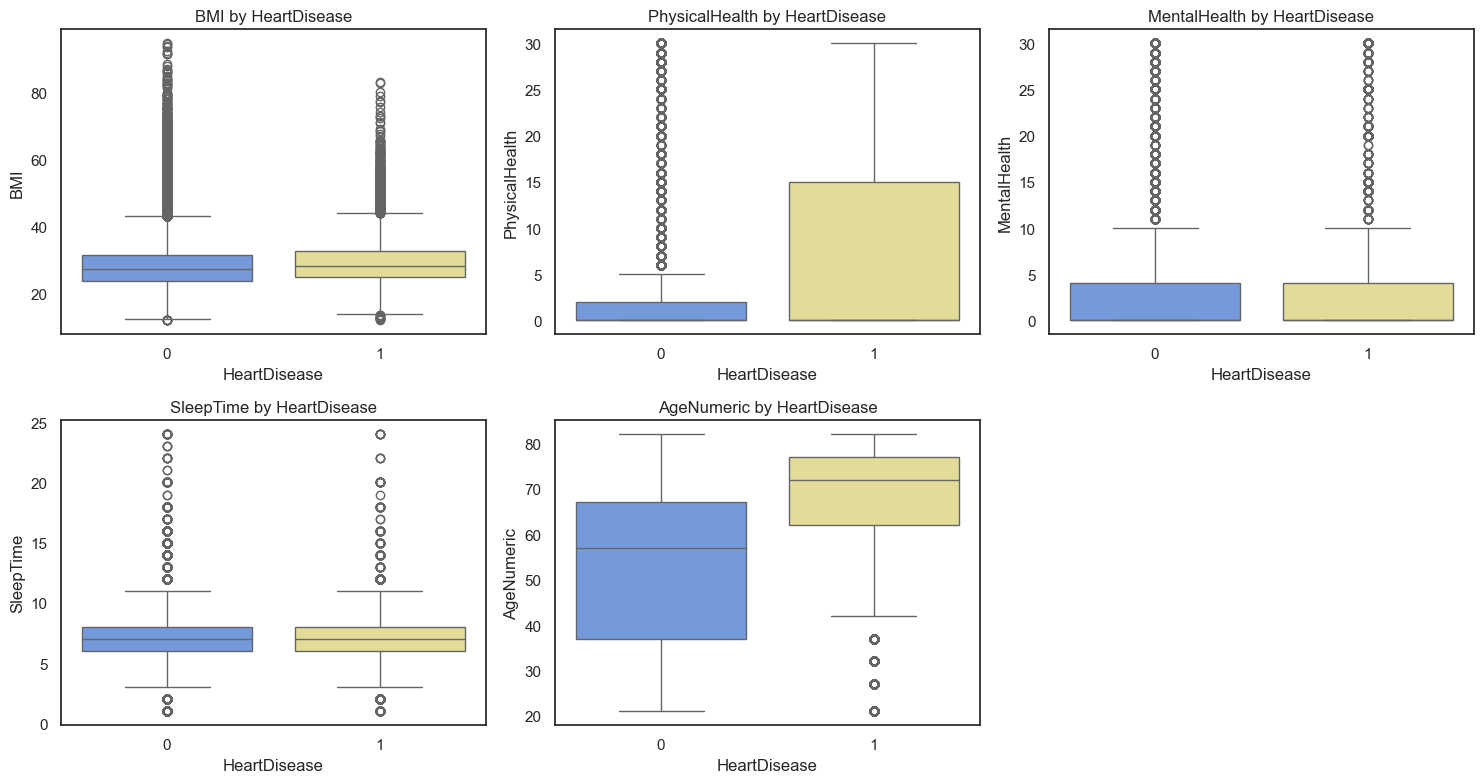

/tmp/ipykernel_550/4214104072.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No disease", "Disease"])


/tmp/ipykernel_550/4214104072.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="HeartDisease", y=col, ax=axes[i],


/tmp/ipykernel_550/4214104072.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No disease", "Disease"])
/tmp/ipykernel_550/4214104072.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x="HeartDisease", y=col, ax=axes[i],


/tmp/ipykernel_550/4214104072.py:7: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[i].set_xticklabels(["No disease", "Disease"])


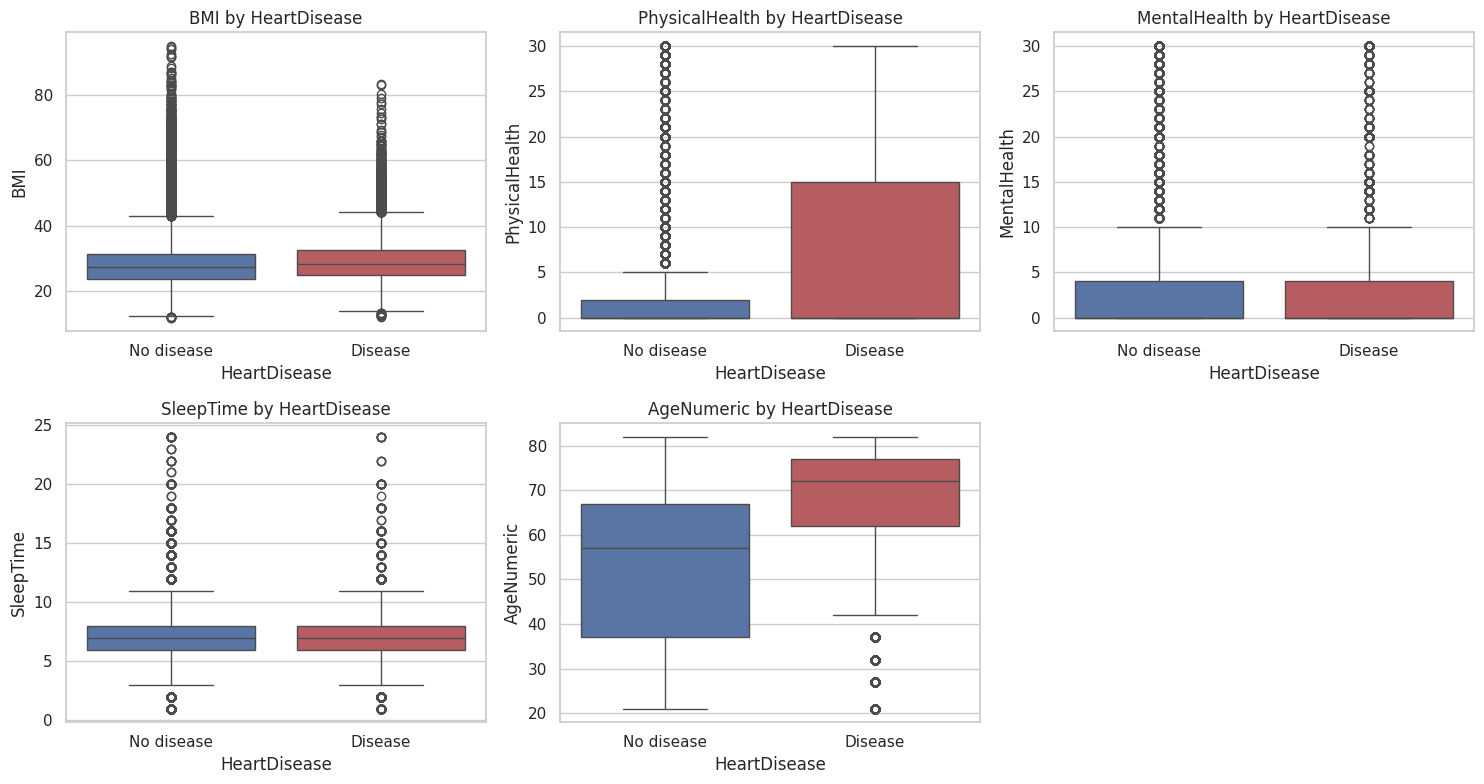

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(continuous_cols):
    sns.boxplot(
        data=df_clean,
        x="HeartDisease",
        y=col,
        hue="HeartDisease",
        ax=axes[i],
        palette=["cornflowerblue", "khaki"],
        legend=False
    )

    axes[i].set_title(f"{col} by HeartDisease")

axes[-1].axis("off")

plt.tight_layout()
plt.show()

In [36]:
for col in continuous_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter rows that fall outside the bounds
    outliers = df_clean[(df_clean[col] < lower_bound) | (df_clean[col] > upper_bound)]

    print(
        f"{col}:"
        f"\n  • Total Outliers: {len(outliers):,} ({len(outliers) / len(df_clean):.2%})"
        f"\n  • Valid Range: [{lower_bound:.2f}, {upper_bound:.2f}]\n"
    )

BMI:
  • Total Outliers: 8,905 (2.95%)
  • Valid Range: [12.60, 43.08]

PhysicalHealth:
  • Total Outliers: 47,136 (15.62%)
  • Valid Range: [-3.00, 5.00]

MentalHealth:
  • Total Outliers: 39,713 (13.16%)
  • Valid Range: [-6.00, 10.00]

SleepTime:
  • Total Outliers: 4,542 (1.51%)
  • Valid Range: [3.00, 11.00]

AgeNumeric:
  • Total Outliers: 0 (0.00%)
  • Valid Range: [4.50, 104.50]



### 5. Distributions of Categorical / binary features

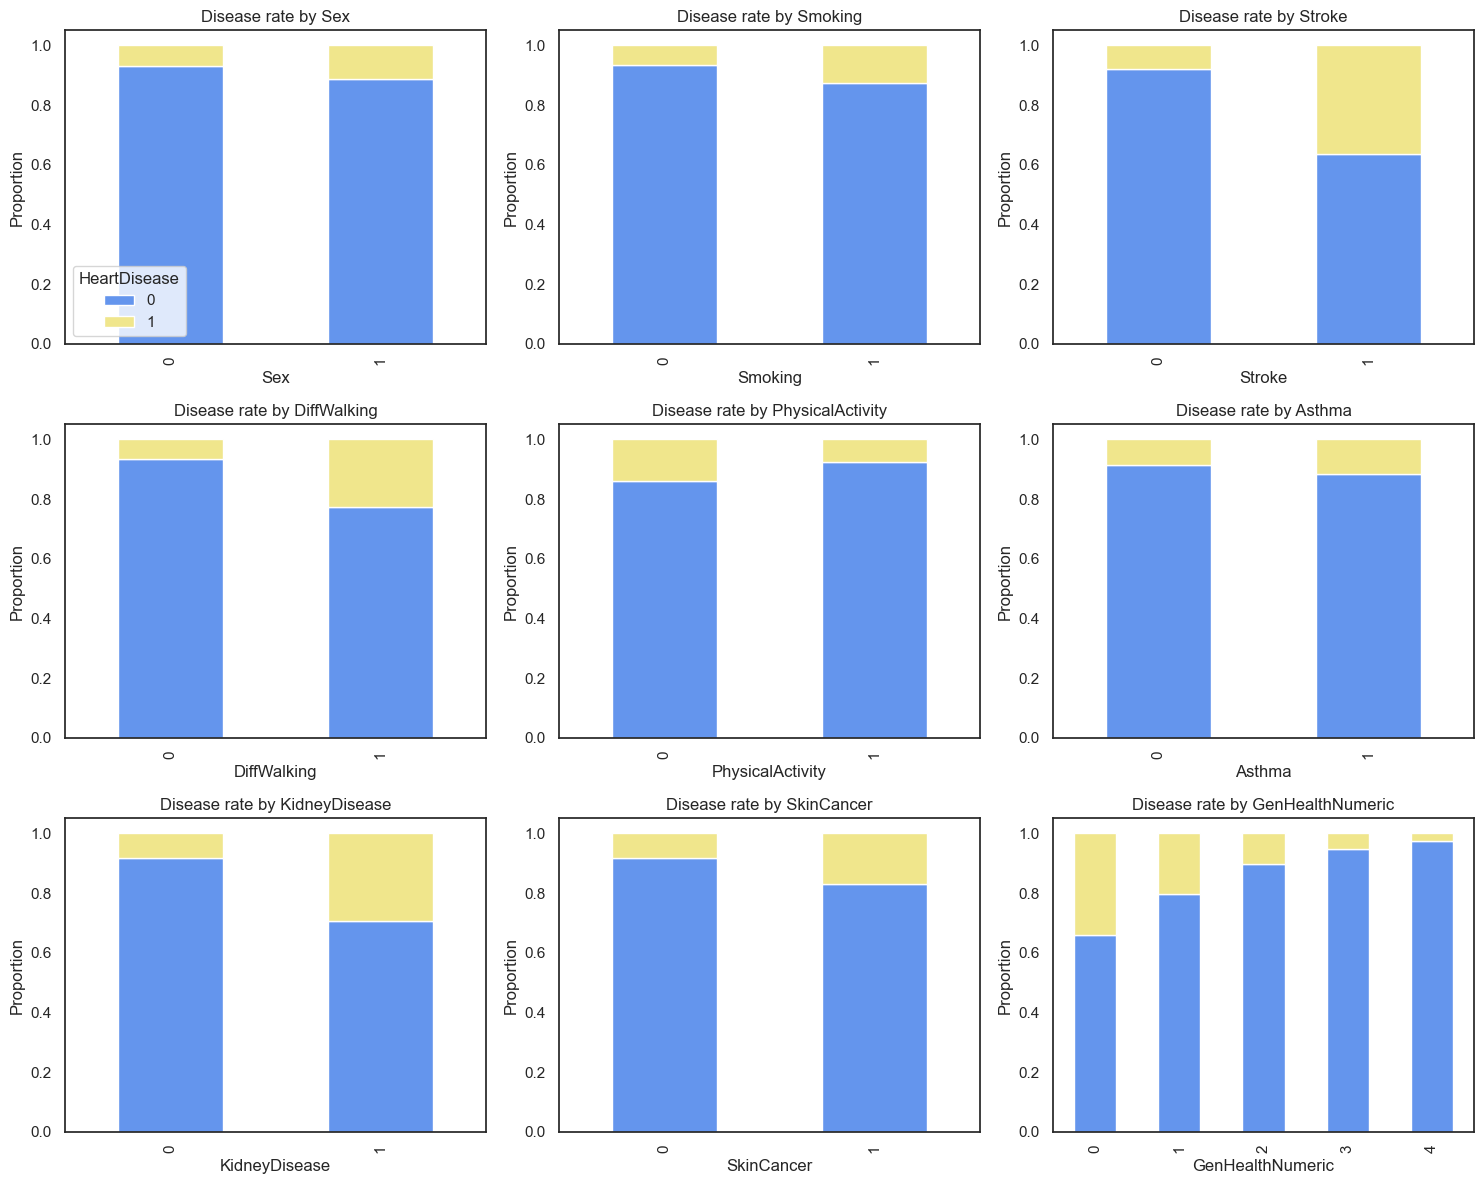

In [16]:
cat_cols_for_plot = ["Sex", "Smoking", "Stroke", "DiffWalking", "PhysicalActivity",
                     "Asthma", "KidneyDisease", "SkinCancer", "GenHealthNumeric"]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(cat_cols_for_plot):
    ct = pd.crosstab(df_clean[col], df_clean["HeartDisease"], normalize="index")
    ct.plot(kind="bar", stacked=True, ax=axes[i], color=["cornflowerblue", "khaki"], legend=(i == 0))
    axes[i].set_title(f"Disease rate by {col}")
    axes[i].set_ylabel("Proportion")
    axes[i].set_xlabel(col)
plt.tight_layout()
plt.show()


**Note the y-axis scale carefully here**: even for the strongest risk factors (e.g. `Stroke`,
`KidneyDisease`), the disease-positive share of each bar is a modest slice, not close to 50% --
another visual reminder of the ~9% base rate. A feature can be a *real, meaningful* risk factor and
still leave most respondents in that category disease-free.


### 6.  Correlation heatmap (numeric / encoded columns)

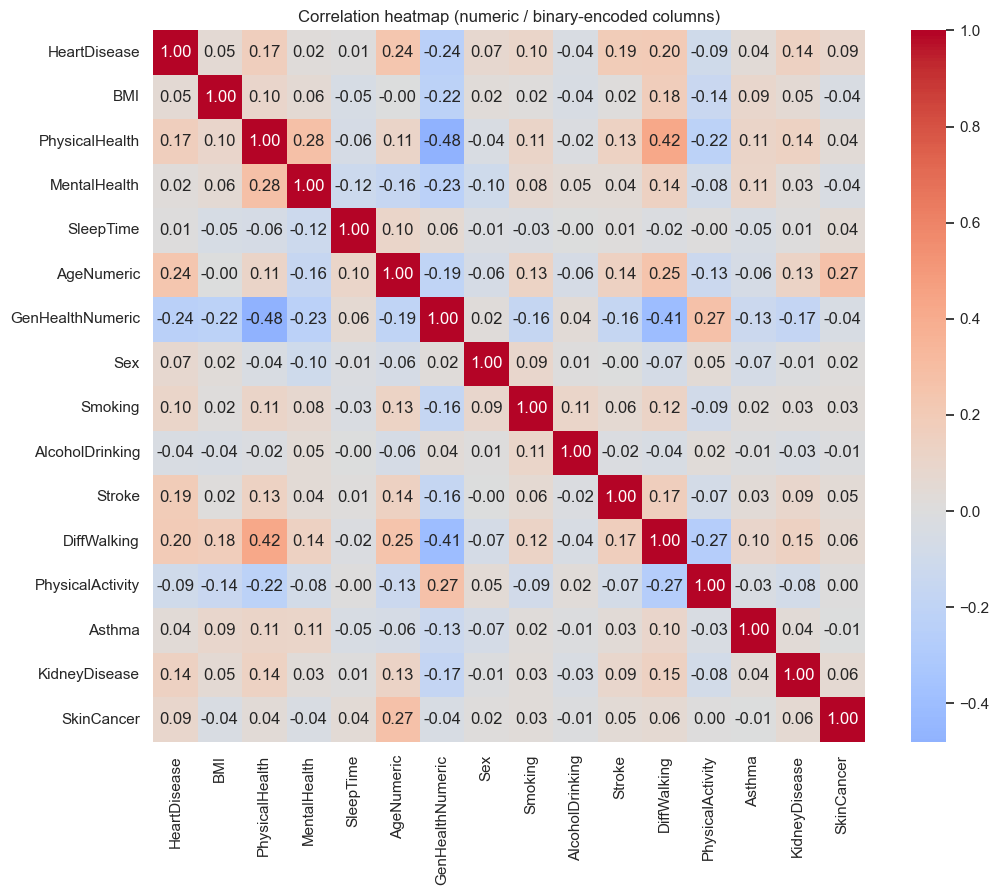

Correlation with HeartDisease, sorted:
AgeNumeric          0.238720
DiffWalking         0.196420
Stroke              0.194665
PhysicalHealth      0.165235
KidneyDisease       0.142672
Smoking             0.104524
SkinCancer          0.090644
Sex                 0.074435
BMI                 0.047260
Asthma              0.035784
MentalHealth        0.020913
SleepTime           0.010834
AlcoholDrinking    -0.036289
PhysicalActivity   -0.093597
GenHealthNumeric   -0.237920
Name: HeartDisease, dtype: float64


In [37]:
numeric_for_corr = ["HeartDisease", "BMI", "PhysicalHealth", "MentalHealth", "SleepTime",
                    "AgeNumeric", "GenHealthNumeric", "Sex"] + binary_cols

plt.figure(figsize=(11, 9))
corr = df_clean[numeric_for_corr].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Correlation heatmap (numeric / binary-encoded columns)")
plt.tight_layout()
plt.show()

print("Correlation with HeartDisease, sorted:")
print(corr["HeartDisease"].drop("HeartDisease").sort_values(ascending=False))


**EDA takeaways:**
- `AgeNumeric`, `GenHealthNumeric` (inverse: worse self-rated health -> higher disease rate),
  `DiffWalking`, and `Stroke` show the strongest associations with heart disease.
- `Sex` shows a modest positive correlation (men somewhat more likely to report heart disease),
  consistent with established epidemiology.
- No individual feature correlates anywhere close to strongly enough to "solve" the problem alone
  -- this is a genuinely multi-factor risk pattern, and also a hint that no single model will reach
  very high recall on this minority class without deliberately addressing the imbalance (Section 6).


# Section 4 : Supervised Baseline — Logistic Regression

We define the classification problem, split the data (stratified, to preserve the ~9% minority
class ratio in both train and test), and train a Logistic Regression baseline with
**`class_weight="balanced"`** -- without this, a model trained on 91/9 imbalanced data will simply
learn to predict the majority class almost every time, which is not a useful model even if its raw
accuracy looks high.


### 1. Splitting the data into training and testing

In [18]:
feature_cols = [c for c in df_clean.columns
                if c not in ["HeartDisease", "AgeCategory", "GenHealth"]]
X = df_clean[feature_cols].copy()
y = df_clean["HeartDisease"].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)
print("Train shape:", X_train.shape, " Test shape:", X_test.shape)
print("Train positive rate:", y_train.mean().round(4))
print("Test positive rate:", y_test.mean().round(4))


Train shape: (241373, 17)  Test shape: (60344, 17)
Train positive rate: 0.0904
Test positive rate: 0.0903


In [19]:
numeric_features = ["BMI", "PhysicalHealth", "MentalHealth", "SleepTime",
                    "AgeNumeric", "GenHealthNumeric"]
nominal_categorical_features = ["Race", "Diabetic"]
# Sex + all binary_cols are already 0/1 -- passed through unchanged (no scaling needed for binaries)
passthrough_features = ["Sex"] + binary_cols

preprocessor_basic = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), nominal_categorical_features),
    ("bin", "passthrough", passthrough_features),
])


In [20]:
baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor_basic),
    ("classifier", LogisticRegression(max_iter=1000, class_weight="balanced",
                                       random_state=RANDOM_STATE)),
])

baseline_model.fit(X_train, y_train)
y_pred_baseline = baseline_model.predict(X_test)
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

print("Baseline Logistic Regression -- Test set performance")
print("Accuracy:          ", round(accuracy_score(y_test, y_pred_baseline), 3))
print("Balanced accuracy:  ", round(balanced_accuracy_score(y_test, y_pred_baseline), 3))
print("Precision:          ", round(precision_score(y_test, y_pred_baseline), 3))
print("Recall:             ", round(recall_score(y_test, y_pred_baseline), 3))
print("F1-score:           ", round(f1_score(y_test, y_pred_baseline), 3))
print("ROC-AUC:            ", round(roc_auc_score(y_test, y_proba_baseline), 3))


Baseline Logistic Regression -- Test set performance
Accuracy:           0.743
Balanced accuracy:   0.755
Precision:           0.227
Recall:              0.77
F1-score:            0.351
ROC-AUC:             0.832


Notice **accuracy alone would be misleading** here -- compare it against balanced accuracy
and recall. `class_weight="balanced"` trades some raw accuracy for dramatically better recall on
the disease-positive class, which is the actual goal of a screening-oriented model.


# Section 5 : Model Comparison — Random Forest (deliberately shallow)

A second classifier for comparison, using the **same split and preprocessing**. Given the earlier
concern that a complex model can be a poor match for the data, this Random Forest is deliberately
kept **shallow** (`max_depth=8`, moderate `n_estimators`) rather than tuned for maximum accuracy --
the goal is a fair, interpretable comparison to the linear baseline, not squeezing out the last
fraction of a percent by over-fitting to this specific train/test split.


In [21]:
rf_model = Pipeline(steps=[
    ("preprocessor", preprocessor_basic),
    ("classifier", RandomForestClassifier(
        n_estimators=150, max_depth=8, n_jobs=1,
        class_weight="balanced", random_state=RANDOM_STATE
    )),
])

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

print("Random Forest -- Test set performance")
print("Accuracy:          ", round(accuracy_score(y_test, y_pred_rf), 3))
print("Balanced accuracy:  ", round(balanced_accuracy_score(y_test, y_pred_rf), 3))
print("Precision:          ", round(precision_score(y_test, y_pred_rf), 3))
print("Recall:             ", round(recall_score(y_test, y_pred_rf), 3))
print("F1-score:           ", round(f1_score(y_test, y_pred_rf), 3))
print("ROC-AUC:            ", round(roc_auc_score(y_test, y_proba_rf), 3))


Random Forest -- Test set performance
Accuracy:           0.719
Balanced accuracy:   0.756
Precision:           0.216
Recall:              0.802
F1-score:            0.34
ROC-AUC:             0.828


In [22]:
comparison = pd.DataFrame({
    "Logistic Regression": [
        accuracy_score(y_test, y_pred_baseline),
        balanced_accuracy_score(y_test, y_pred_baseline),
        precision_score(y_test, y_pred_baseline),
        recall_score(y_test, y_pred_baseline),
        f1_score(y_test, y_pred_baseline),
        roc_auc_score(y_test, y_proba_baseline),
    ],
    "Random Forest": [
        accuracy_score(y_test, y_pred_rf),
        balanced_accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf),
        roc_auc_score(y_test, y_proba_rf),
    ],
}, index=["Accuracy", "Balanced Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"])

comparison.round(3)


,Logistic Regression,Random Forest
Accuracy,0.743,0.719
Balanced Accuracy,0.755,0.756
Precision,0.227,0.216
Recall,0.770,0.802
F1-score,0.351,0.340
ROC-AUC,0.832,0.828


**Interpretation:** if the shallow Random Forest's ROC-AUC/F1 is only marginally better than
the linear baseline, that itself is a legitimate, useful finding -- it suggests the relationship
between these lifestyle/health survey features and heart disease is largely additive/linear rather
than requiring complex non-linear interactions, i.e. the "simple data doesn't need a complicated
model" intuition may hold up quantitatively, not just as a hunch. State whichever result you
actually get; don't force a narrative onto the numbers.


## 6. Evaluation — Cross-Validation, Confusion Matrix, ROC

5-fold **stratified** cross-validation on the training data (preserving the ~9% positive rate in
every fold), then a closer look at the held-out test set.


In [23]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)
scoring = ["accuracy", "balanced_accuracy", "precision", "recall", "f1", "roc_auc"]

cv_results = {}
for name, model in [("Logistic Regression", baseline_model), ("Random Forest", rf_model)]:
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
    cv_results[name] = {m: (scores[f"test_{m}"].mean(), scores[f"test_{m}"].std()) for m in scoring}

cv_summary = pd.DataFrame({
    name: {metric: f"{mean:.3f} +/- {std:.3f}" for metric, (mean, std) in metrics.items()}
    for name, metrics in cv_results.items()
})
cv_summary


,Logistic Regression,Random Forest
accuracy,0.744 +/- 0.002,0.722 +/- 0.003
balanced_accuracy,0.760 +/- 0.001,0.758 +/- 0.002
precision,0.230 +/- 0.001,0.218 +/- 0.002
recall,0.779 +/- 0.001,0.802 +/- 0.003
f1,0.355 +/- 0.002,0.343 +/- 0.003
roc_auc,0.837 +/- 0.000,0.834 +/- 0.001


With ~240K training rows, cross-validation standard deviations should be small -- if they
are, that's good evidence the single test-set numbers above are stable and not a lucky/unlucky
split.


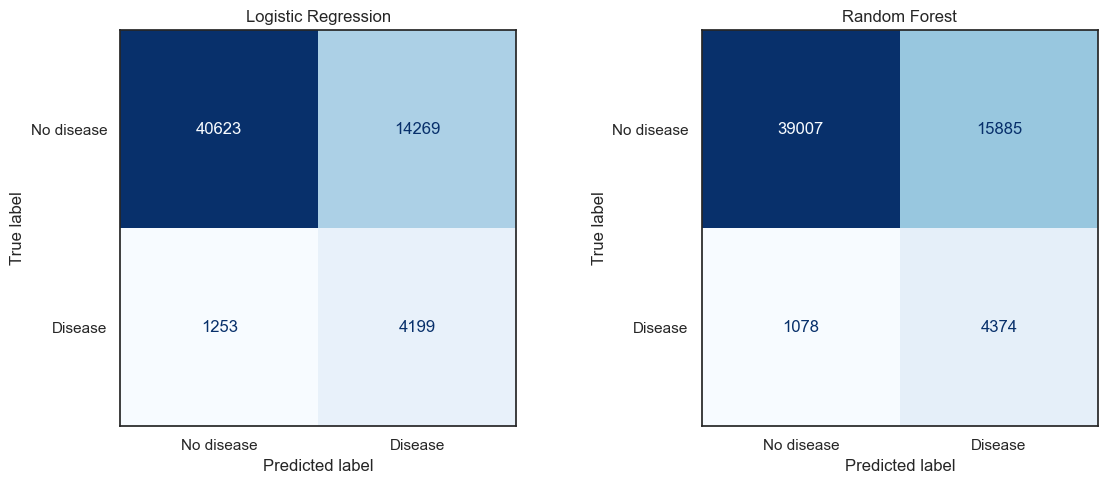

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, (name, y_pred) in zip(axes, [("Logistic Regression", y_pred_baseline), ("Random Forest", y_pred_rf)]):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No disease", "Disease"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False, values_format="d")
    ax.set_title(name)
plt.tight_layout()
plt.show()

In [25]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
tn, fp, fn, tp = cm_rf.ravel()
print(f"Random Forest confusion matrix -> TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Of {tp + fn} actual disease cases, the model correctly flagged {tp} ({tp/(tp+fn):.1%})")
print(f"Of {tn + fp} actual healthy respondents, {fp} were incorrectly flagged ({fp/(tn+fp):.1%})")


Random Forest confusion matrix -> TN=39007, FP=15885, FN=1078, TP=4374
Of 5452 actual disease cases, the model correctly flagged 4374 (80.2%)
Of 54892 actual healthy respondents, 15885 were incorrectly flagged (28.9%)


**Plain-language interpretation:**
- **False negatives (FN)** = respondents predicted healthy who actually reported heart disease.
  On imbalanced data like this, a naive model tends to produce *many* of these unless class weights
  or resampling are used, because "always predict healthy" is a low-loss shortcut on 91% of rows.
  In a screening context, this is the costlier error -- a real at-risk person is missed entirely.
- **False positives (FP)** = healthy respondents incorrectly flagged as at-risk. Costs follow-up
  burden and anxiety, but is not as costly as a missed case in this framing.
- Because `class_weight="balanced"` was used for both models, recall on the disease class should be
  substantially higher than an un-weighted model would achieve, at some cost to precision and raw
  accuracy -- that tradeoff is deliberate and appropriate for a screening-style problem, and is the
  central methodological point of this whole evaluation section.


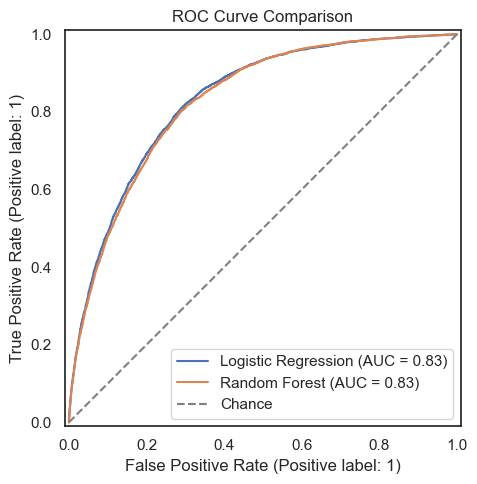

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_proba_baseline, name="Logistic Regression", ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name="Random Forest", ax=ax)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Chance")
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.tight_layout()
plt.show()


In [27]:
print("Classification report -- Random Forest\n")
print(classification_report(y_test, y_pred_rf, target_names=["No disease", "Disease"]))


Classification report -- Random Forest

              precision    recall  f1-score   support

  No disease       0.97      0.71      0.82     54892
     Disease       0.22      0.80      0.34      5452

    accuracy                           0.72     60344
   macro avg       0.59      0.76      0.58     60344
weighted avg       0.90      0.72      0.78     60344



In [33]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

def plot_loss_learning_curves(models, X, y, cv=2, random_state=42):
    """
    Plot training and validation log loss against training set size.
    """

    fig, ax = plt.subplots(figsize=(7, 5))

    colors = {
        "Logistic Regression": "#4C72B0",
        "Random Forest": "#C44E52"
    }

    for name, model in models.items():

        train_sizes, train_scores, val_scores = learning_curve(
            model,
            X,
            y,
            cv=cv,
            scoring="neg_log_loss",
            train_sizes=np.linspace(0.2, 1.0, 4),
            random_state=random_state,
            n_jobs=-1
        )

        train_loss = -train_scores.mean(axis=1)
        val_loss = -val_scores.mean(axis=1)

        ax.plot(
            train_sizes,
            train_loss,
            marker="o",
            linestyle="--",
            color=colors[name],
            alpha=0.6,
            label=f"{name} (train)"
        )

        ax.plot(
            train_sizes,
            val_loss,
            marker="o",
            linestyle="-",
            color=colors[name],
            label=f"{name} (validation)"
        )

    ax.set_xlabel("Training Set Size")
    ax.set_ylabel("Log Loss (Lower is Better)")
    ax.set_title("Learning Curves: Log Loss vs. Training Set Size")
    ax.legend()

    plt.tight_layout()
    plt.show()

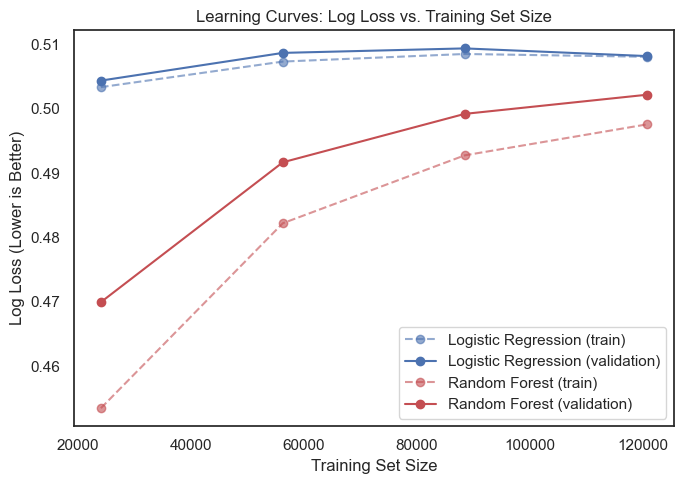

In [34]:
plot_loss_learning_curves(
    {
        "Logistic Regression": baseline_model,
        "Random Forest": rf_model
    },
    X_train,
    y_train
)

## 7. Feature Engineering & Pipeline

Engineered features grounded in how the source variables are actually defined, then a single
reusable `Pipeline`, then a before/after comparison under identical cross-validation folds.

**Engineered features:**
- `BMICategory` = BMI binned per standard CDC categories (underweight/normal/overweight/obese)
- `TotalUnhealthyDays` = `PhysicalHealth` + `MentalHealth` (combined self-reported bad days/month)
- `ComorbidityCount` = count of positive risk/condition flags (Stroke, Diabetic != "No", Asthma,
  KidneyDisease, DiffWalking) -- a simple composite burden score
- `Age_x_Comorbidity` = interaction between `AgeNumeric` and `ComorbidityCount`
- `PoorGenHealth_x_DiffWalking` = interaction flag capturing compounding mobility + self-rated
  health risk


In [29]:
def engineer_features(X_in: pd.DataFrame) -> pd.DataFrame:
    """Add engineered features grounded in the source columns' definitions."""
    X = X_in.copy()

    X["BMICategory"] = pd.cut(
        X["BMI"], bins=[0, 18.5, 25, 30, 100],
        labels=["underweight", "normal", "overweight", "obese"]
    ).astype(str)

    X["TotalUnhealthyDays"] = X["PhysicalHealth"] + X["MentalHealth"]

    diabetic_positive = X["Diabetic"].isin(["Yes", "Yes (during pregnancy)"]).astype(int)
    X["ComorbidityCount"] = (
        X["Stroke"] + diabetic_positive + X["Asthma"] + X["KidneyDisease"] + X["DiffWalking"]
    )

    X["Age_x_Comorbidity"] = X["AgeNumeric"] * X["ComorbidityCount"]
    X["PoorGenHealth_x_DiffWalking"] = (X["GenHealthNumeric"] <= 1).astype(int) * X["DiffWalking"]

    return X

X_train_fe = engineer_features(X_train)
X_test_fe = engineer_features(X_test)
X_train_fe[["BMICategory", "TotalUnhealthyDays", "ComorbidityCount",
            "Age_x_Comorbidity", "PoorGenHealth_x_DiffWalking"]].head()


,BMICategory,TotalUnhealthyDays,ComorbidityCount,Age_x_Comorbidity,PoorGenHealth_x_DiffWalking
169471,obese,3.0,0,0,0
6968,normal,0.0,0,0,0
199093,obese,14.0,1,52,0
247108,normal,0.0,0,0,0
45276,obese,4.0,0,0,0


In [30]:
engineered_numeric = numeric_features + ["TotalUnhealthyDays", "ComorbidityCount",
                                          "Age_x_Comorbidity", "PoorGenHealth_x_DiffWalking"]
engineered_nominal = nominal_categorical_features + ["BMICategory"]

preprocessor_fe = ColumnTransformer(transformers=[
    ("num", StandardScaler(), engineered_numeric),
    ("cat", OneHotEncoder(handle_unknown="ignore"), engineered_nominal),
    ("bin", "passthrough", passthrough_features),
])

rf_fe_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor_fe),
    ("classifier", RandomForestClassifier(
        n_estimators=150, max_depth=8, n_jobs=1,
        class_weight="balanced", random_state=RANDOM_STATE
    )),
])

rf_fe_pipeline.fit(X_train_fe, y_train)
y_pred_fe = rf_fe_pipeline.predict(X_test_fe)
y_proba_fe = rf_fe_pipeline.predict_proba(X_test_fe)[:, 1]

print("Random Forest + engineered features -- Test set performance")
print("Accuracy:          ", round(accuracy_score(y_test, y_pred_fe), 3))
print("Balanced accuracy:  ", round(balanced_accuracy_score(y_test, y_pred_fe), 3))
print("Precision:          ", round(precision_score(y_test, y_pred_fe), 3))
print("Recall:             ", round(recall_score(y_test, y_pred_fe), 3))
print("F1-score:           ", round(f1_score(y_test, y_pred_fe), 3))
print("ROC-AUC:            ", round(roc_auc_score(y_test, y_proba_fe), 3))


Random Forest + engineered features -- Test set performance
Accuracy:           0.731
Balanced accuracy:   0.754
Precision:           0.221
Recall:              0.782
F1-score:            0.345
ROC-AUC:             0.827


In [31]:
# Fair before/after comparison using the SAME cross-validation folds
cv_scores_before = cross_validate(rf_model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=1)
cv_scores_after = cross_validate(rf_fe_pipeline, X_train_fe, y_train, cv=cv, scoring=scoring, n_jobs=1)

fe_comparison = pd.DataFrame({
    "Random Forest (raw features)": {m: f"{cv_scores_before[f'test_{m}'].mean():.3f}" for m in scoring},
    "Random Forest (+ engineered features)": {m: f"{cv_scores_after[f'test_{m}'].mean():.3f}" for m in scoring},
})
fe_comparison


,Random Forest (raw features),Random Forest (+ engineered features)
accuracy,0.722,0.732
balanced_accuracy,0.758,0.758
precision,0.218,0.223
recall,0.802,0.789
f1,0.343,0.348
roc_auc,0.834,0.832


**Interpretation:** compare the two columns above, especially F1 and recall (the metrics that
actually matter on this imbalanced target). If the engineered-feature version doesn't clearly beat
the raw-feature version, that is a legitimate, reportable finding: the engineered composites may be
redundant with information the model could already extract from the individual columns. State
whichever result actually came out -- don't reach for a positive-sounding conclusion the numbers
don't support.


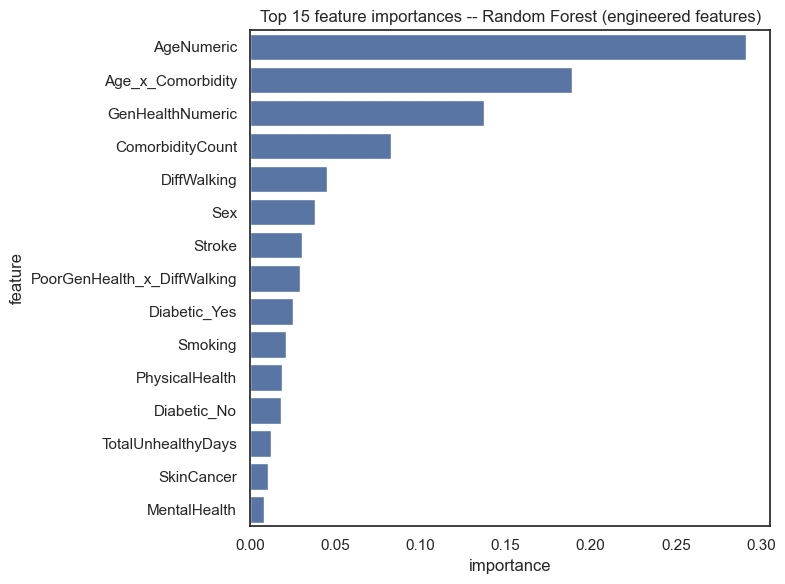

In [38]:
ohe = rf_fe_pipeline.named_steps["preprocessor"].named_transformers_["cat"]
cat_names = ohe.get_feature_names_out(engineered_nominal)
all_feature_names = engineered_numeric + list(cat_names) + passthrough_features

importances = rf_fe_pipeline.named_steps["classifier"].feature_importances_
importance_df = pd.DataFrame({"feature": all_feature_names, "importance": importances})
importance_df = importance_df.sort_values("importance", ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x="importance", y="feature", color="#4C72B0")
plt.title("Top 15 feature importances -- Random Forest (engineered features)")
plt.tight_layout()
plt.show()


# Summary, Findings & Limitations

## Data Preparation

The dataset originally contained 319,795 survey responses. There were no missing values, but 18,078 exact duplicate rows were removed. However, because most features have a small number of possible categories and there is no respondent ID, some identical rows may represent different people who happened to give the same answers.

The ordinal features, `AgeCategory` and `GenHealth`, were converted into numeric scales to preserve their natural order. Nominal features, such as `Race` and `Diabetic`, were one-hot encoded because their categories do not have a natural order.

## The Main Challenge: Class Imbalance

Only about 8.6% of respondents reported having heart disease. This means that accuracy alone is not a reliable metric. A model could achieve high accuracy by predicting that most respondents do not have heart disease while missing many actual cases.

For this reason, the models were mainly evaluated using precision, recall, F1-score, and ROC-AUC. Class weighting was also used to give more importance to the minority class during training.

## Supervised Modeling

A Logistic Regression model was used as a baseline and compared with a shallow Random Forest model. Both models were evaluated using the same data splits, preprocessing steps, and 5-fold stratified cross-validation.

The Random Forest was intentionally kept shallow (`max_depth=8`) to avoid adding unnecessary complexity. The goal was not simply to achieve the highest possible accuracy, but to build models that could better identify heart disease cases while maintaining a reasonable balance between recall and precision.

## Feature Engineering

Several additional features were created, including BMI categories, total unhealthy days, a comorbidity count, and interaction features. These engineered features were compared with the original features using the same cross-validation process to determine whether they improved the models enough to justify the additional complexity.

## Limitations

This dataset is based mainly on self-reported survey responses, which may contain reporting errors or inaccuracies. In addition, the dataset can identify patterns associated with heart disease, but it cannot prove that a specific feature causes heart disease.